In [7]:
%matplotlib inline

import ast
import IPython.display as ipd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import Normalizer, MinMaxScaler, normalize
from sklearn.cluster import MeanShift, KMeans, AffinityPropagation, AgglomerativeClustering, FeatureAgglomeration, SpectralClustering, estimate_bandwidth
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, silhouette_score, v_measure_score


from scipy.spatial.distance import cdist, pdist

# from sklearn import cluster

In [8]:
'''Data has already been preprocessed'''
# Read data
tracks = pd.read_csv('tracks_training.csv', index_col=0)
tracks.head()

,acousticness,danceability,energy,instrumentalness,liveness,speechiness,tempo,valence
track_id,,,,,,,,
2,0.307539,0.498863,0.468293,0.007844,0.131117,0.117583,0.474367,0.425621
3,0.294663,0.416047,0.643350,0.001457,0.083329,0.363455,0.377140,0.211895
5,0.033163,0.567520,0.533955,0.000530,0.284035,0.094841,0.279499,0.473205
10,0.462145,0.319621,0.448963,0.468825,0.056076,0.016018,0.201340,0.467933
134,0.315940,0.358572,0.391528,0.013584,0.067466,0.367152,0.297662,0.624640


### Task 1: Find appropriate K-Values based on the Elbow method

#### 1.1 Cluster data and compute scores

Number of clusters (k):  1     Distance to Cluster Center: 0.46522131601404315
Number of clusters (k):  2     Distance to Cluster Center: 0.3873099509894153
Number of clusters (k):  3     Distance to Cluster Center: 0.3421785460386173
Number of clusters (k):  4     Distance to Cluster Center: 0.31755063148633544
Number of clusters (k):  5     Distance to Cluster Center: 0.2988640236920539
Number of clusters (k):  6     Distance to Cluster Center: 0.2861227999835759
Number of clusters (k):  7     Distance to Cluster Center: 0.27517516744684417
Number of clusters (k):  8     Distance to Cluster Center: 0.2677287799859668
Number of clusters (k):  9     Distance to Cluster Center: 0.26094294953749386
Number of clusters (k):  10     Distance to Cluster Center: 0.25653548536571524
Number of clusters (k):  11     Distance to Cluster Center: 0.25282353169154476
Number of clusters (k):  12     Distance to Cluster Center: 0.24755291291197512
Number of clusters (k):  13     Distance to Cluster Ce

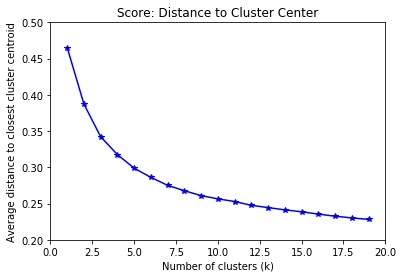

In [9]:
# for each k = 1 : 20 (including 20), cluster data and compute scores

# count the score using Distance to Cluster Center

distance_to_cluster_centre = []

for k in range(1,20):
    kmeans = KMeans(n_clusters=k)  
    kmeans.fit(tracks)
    distance = np.min(kmeans.transform(tracks),axis=1)
    average_distance = np.mean(distance)
    distance_to_cluster_centre.append(average_distance)
    print("Number of clusters (k): ", k, "    Distance to Cluster Center:", average_distance )

clusters = np.arange(len(distance_to_cluster_centre))+1
plt.plot(clusters, distance_to_cluster_centre,'b*-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Average distance to closest cluster centroid')
plt.title('Score: Distance to Cluster Center')
plt.ylim(0.2,0.5)
plt.xlim(0,20)
plt.show()

#### 1.2 Visualize scores
Plot the K value against the Error.

Text(0.5, 1.0, 'Elbow Method')

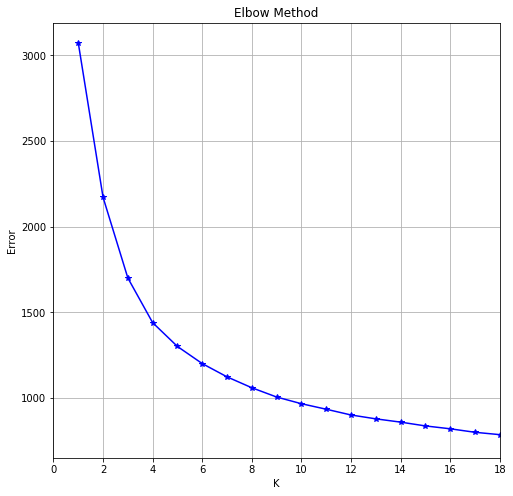

In [6]:
# x-axis: K
# y-axis: Error
# title of plot: Elbow Method

Ks = np.arange(1, 20)
km = [KMeans(n_clusters=i, random_state=0) for i in Ks]
score = [-km[i].fit(tracks).score(tracks) for i in range(len(km))]
Ks.dtype = int
plt.figure(figsize=(8,8))
plt.plot(Ks,score,'b*-')
#plt.xlim(0,20)
plt.xlim(0,18)
plt.grid(True)
plt.xlabel('K')
plt.ylabel('Error')
plt.title('Elbow Method')

#### 1.3 What is the optimal range of number of clusters based on the Elbow method? 

<font color=blue>
Optimal range of number of clusters is between 4 to 10 clusters. 
The best cluster looks like 4, since the slope starts less steep starts from 4 (the difference between number of error is less start from cluster 4)
</font>

### Task 2 Analyze data given 9 genre (K = 9)
#### 2.1 Fit the data and show the genre attributes of cluster centers 

In [10]:
# genre attributes:['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'speechiness', 'tempo', 'valence']
audio_cols = ['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'speechiness', 'tempo', 'valence']

kmeans = KMeans(n_clusters=9, random_state=0, n_jobs=-1)
kmeans.fit(tracks)
labels = kmeans.labels_
labels_unique = np.unique(labels)
cluster_centers = kmeans.cluster_centers_

kmeans_clusters = pd.DataFrame(cluster_centers, columns=audio_cols)
kmeans_clusters['cluster'] = ['KM{}'.format(i) for i in labels_unique]
kmeans_clusters['method'] = 'KMeans'
clusters_K9 = kmeans_clusters
cols = ['cluster'] + audio_cols + ['method']
clusters_K9 = clusters_K9[cols]

clusters_K9

,cluster,acousticness,danceability,energy,instrumentalness,liveness,speechiness,tempo,valence,method
0,KM0,0.458164,0.423632,0.398236,0.054717,0.140368,0.120487,0.339701,0.438929,KMeans
1,KM1,0.114715,0.438949,0.315759,0.660836,0.118298,0.069973,0.349670,0.178197,KMeans
2,KM2,0.491666,0.323677,0.289824,0.498699,0.102790,0.051470,0.281683,0.411778,KMeans
3,KM3,0.067699,0.265521,0.579826,0.571658,0.147228,0.057973,0.358632,0.194320,KMeans
4,KM4,0.719879,0.363069,0.153142,0.063816,0.159604,0.120690,0.320653,0.249395,KMeans
5,KM5,0.100297,0.402117,0.434959,0.512237,0.101321,0.055850,0.305494,0.457807,KMeans
6,KM6,0.488634,0.232328,0.455069,0.542399,0.129857,0.054604,0.309402,0.157010,KMeans
7,KM7,0.629089,0.253951,0.124670,0.597576,0.124004,0.039621,0.272991,0.133622,KMeans
8,KM8,0.074129,0.421298,0.585251,0.050908,0.168277,0.085925,0.394869,0.412004,KMeans


#### 2.2 Use a heatmap to show the audio feature values of each genre

Text(61.5, 0.5, 'KMeansLabel')

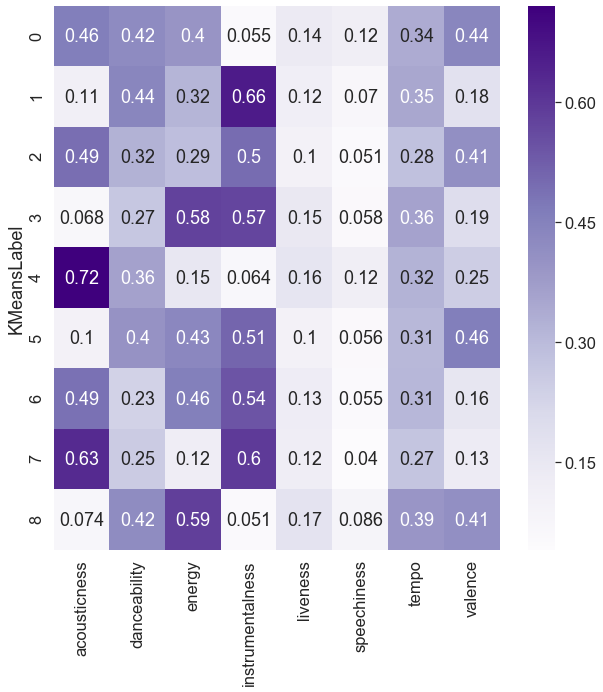

In [11]:
plt.figure(figsize=(10,10))
sns.set(font_scale=1.5)
sns.heatmap(
    data=clusters_K9.loc[clusters_K9.method=='KMeans', audio_cols],
    cmap='Purples',
    annot=True
)
plt.ylabel("KMeansLabel")

#### 2.3 What do these clusters mean based on this heatmap? 
e.g. KM0: Highly acoustic and instrumental. Low danceability, energy tempo, valence. "Slow & Somber Acoustics"

**Note: please analyze each cluster thoroughly**


- **KM0**: 
<font color=blue>
High acousticness, valence, danceability. Mid tempo. Low instrumentalness, speechness. "Cheerful & Danceable Acoustic " 
<br>    
</font>

- **KM1**: 
<font color=blue>
High instrumentalness, danceability. Mid tempo. Low acousticness, liveness, valence. "Sad & Danceable Instrumental"
<br>    
</font>

- **KM2**: 
<font color=blue>
High instrumentalness, acousticness, valence. Mid danceability. Low speechness, liveness. "Happy & Danceable Acoustics"
<br>    
</font>

- **KM3**:
<font color=blue>
High instrumentalness, energy. Mid tempo. Low speechness, acousticness, valence. "Fast Somber Instrumental"
<br>    
</font>

- **KM4**: 
<font color=blue>
High acousticness. Mid danceability. Low instrumentalness, energy, liveness, speechness. "Slow Dance Acoustics"
<br>    
</font>

- **KM5**: 
<font color=blue>
High instrumentalness, energy, valence. Mid danceability. Low speechness, liveness, acousticnesss. "Happy Upbeat Instrumental"
<br>    
</font>

- **KM6**: 
<font color=blue>
High instrumentalness, energy, acousticness. Low speechness, liveness, valence. "Fast Acoustics Instrumental"
<br>    
</font>

- **KM7**: 
<font color=blue>
High acousticness, instrumentalness. Low speechness, energy, valence. "Slow & Sad Acoustics"
<br>    
</font>

- **KM8**: 
<font color=blue>
High energy, danceability, valence. Mid tempo. Low instrumentalness, acousticness, speechness, liveness. "Happy Energetic Dance Instrumental"
<br>    
</font>

### Task 3: Find the optimal number of clusters using Hierarchical Clustering
#### 3.1 Produce dendrogram using hierarchical clustering.
**hint:based on ward method**

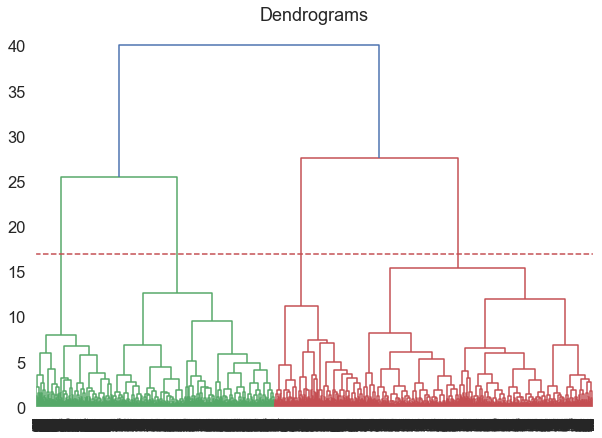

In [12]:
import scipy.cluster.hierarchy as shc

#tracks_scaled = normalize(tracks)
df_tracks = pd.DataFrame(tracks, columns=tracks.columns)
df_tracks.head()

plt.figure(figsize=(10, 7))
plt.title("Dendrograms")
dend= shc.dendrogram(shc.linkage(df_tracks, method='ward'))
plt.axhline(y=17, color='r',linestyle='--')


#### 3.2 What is optimal number of clusters based on Hierarchical Clustering?  

<font color=blue>
<br>
Optimal range of number of clusters is 4 clusters
</font>

#### 3.3 Apply Hierarchical Clustering based on optimal number of clusters.

In [13]:
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(n_clusters = 4, affinity = 'euclidean', linkage = 'ward')
cluster.fit_predict(df_tracks)

array([3, 3, 3, ..., 1, 3, 0], dtype=int64)

#### 3.4 Visualize clusters on a 2D scatter plot w.r.t attributes "acousticness" and "instrumentalness"

Text(0, 0.5, 'instrumentalness')

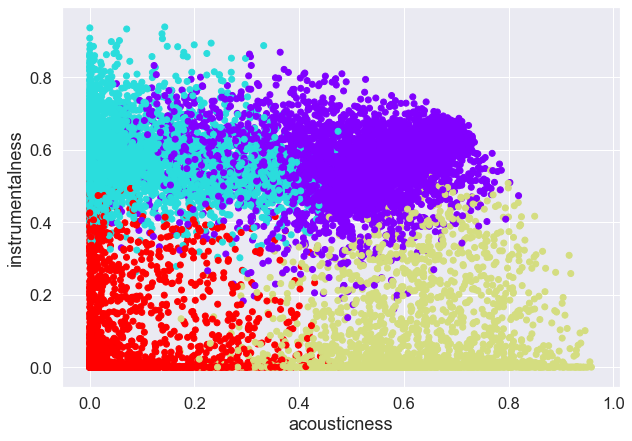

In [14]:
plt.figure(figsize=(10, 7))  
plt.scatter(df_tracks['acousticness'], df_tracks['instrumentalness'], c=cluster.labels_, cmap='rainbow') 

plt.xlabel('acousticness')
plt.ylabel('instrumentalness')